# Week 3 - Emotion Label Clustering Analysis

## Purpose

The 44 emotion labels in KOTE were manually grouped based on their semantic similarities.

The purpose of this analysis is to examine whether semantically related emotion labels also show similar patterns in the dataset, especially in their frequency and co-occurrence.

The original 44 labels are preserved and the clusters are used only for exploratory analysis.

In [1]:
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"
RESULTS_DIR = PROJECT_ROOT / "results"

FIGURE_DIR = RESULTS_DIR / "figures"
METRICS_DIR = RESULTS_DIR / "metrics"

SRC_DIR = PROJECT_ROOT / "src"

import sys

sys.path.append(str(SRC_DIR))

from utils.labels import LABELS
from utils.label_clusters_initial import (
    LABEL_CLUSTERS,
    UNCLUSTERED_LABELS,
    SPECIAL_LABELS,
)

train_path = DATA_DIR / "train.tsv"
val_path = DATA_DIR / "val.tsv"
test_path = DATA_DIR / "test.tsv"

train_df = pd.read_csv(train_path, sep="\t", header=None, names=["id", "text", "labels"])
val_df = pd.read_csv(val_path, sep="\t", header=None, names=["id", "text", "labels"])
test_df = pd.read_csv(test_path, sep="\t", header=None, names=["id", "text", "labels"])

In [2]:
for cluster_name, labels in LABEL_CLUSTERS.items():
    print(f"{cluster_name}: {len(labels)} labels")
    print(labels)
    print()

hostility_anger: 5 labels
['불평/불만', '화남/분노', '역겨움/징그러움', '짜증', '증오/혐오']

sadness: 2 labels
['슬픔', '서러움']

boredom_tiredness: 2 labels
['지긋지긋', '재미없음']

exhaustion_avoidance: 3 labels
['힘듦/지침', '귀찮음', '부담/안_내킴']

fear_anxiety: 3 labels
['의심/불신', '공포/무서움', '불안/걱정']

disappointment_frustration: 3 labels
['안타까움/실망', '절망', '패배/자기혐오']

self_reflection: 2 labels
['부끄러움', '죄책감']

gratitude_respect: 2 labels
['고마움', '존경']

affection: 2 labels
['환영/호의', '아껴주는']

satisfaction_stability: 3 labels
['뿌듯함', '편안/쾌적', '흐뭇함(귀여움/예쁨)']

happiness: 3 labels
['즐거움/신남', '행복', '기쁨']

surprise_confusion: 4 labels
['당황/난처', '경악', '놀람', '어이없음']



In [3]:
clustered_labels = [
    label
    for labels in LABEL_CLUSTERS.values()
    for label in labels
]

all_defined_labels = (
    clustered_labels
    + UNCLUSTERED_LABELS
    + SPECIAL_LABELS
)

print("Total labels:", len(LABELS))
print("Defined labels:", len(all_defined_labels))
print("Unique defined labels:", len(set(all_defined_labels)))

missing = set(LABELS) - set(all_defined_labels)
extra = set(all_defined_labels) - set(LABELS)

print("Missing:", missing)
print("Extra:", extra)

Total labels: 44
Defined labels: 44
Unique defined labels: 44
Missing: set()
Extra: set()


In [4]:
cluster_sizes = {
    cluster: len(labels)
    for cluster, labels in LABEL_CLUSTERS.items()
}

cluster_sizes

{'hostility_anger': 5,
 'sadness': 2,
 'boredom_tiredness': 2,
 'exhaustion_avoidance': 3,
 'fear_anxiety': 3,
 'disappointment_frustration': 3,
 'self_reflection': 2,
 'gratitude_respect': 2,
 'affection': 2,
 'satisfaction_stability': 3,
 'happiness': 3,
 'surprise_confusion': 4}

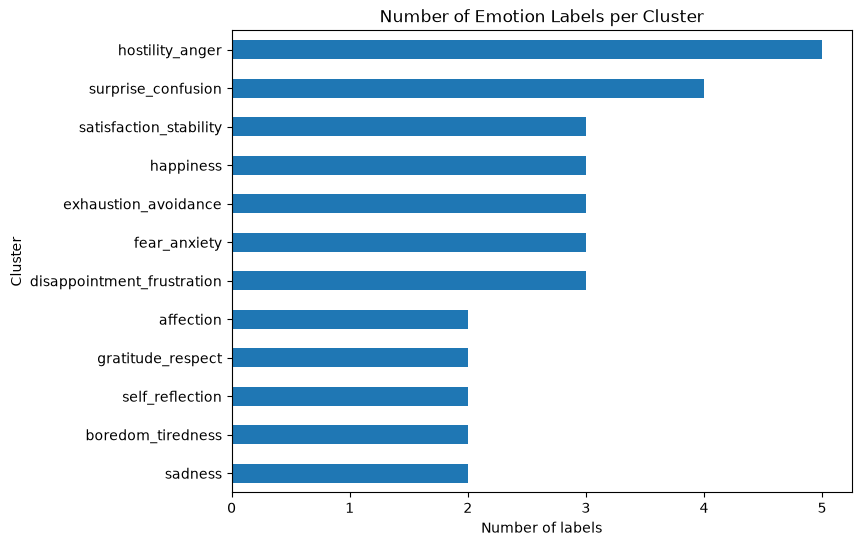

In [5]:
pd.Series(cluster_sizes).sort_values().plot(
    kind="barh",
    figsize=(8, 6)
)

plt.xlabel("Number of labels")
plt.ylabel("Cluster")
plt.title("Number of Emotion Labels per Cluster")
plt.show()

In [6]:
LABEL_TO_ID = {
    label: idx
    for idx, label in enumerate(LABELS)
}

LABEL_TO_ID["화남/분노"]

6

In [7]:
def parse_labels(label_string):
    return [int(x.strip()) for x in label_string.split(",")]

train_df["label_ids"] = train_df["labels"].apply(parse_labels)

print(train_df["label_ids"].iloc[0])
print(type(train_df["label_ids"].iloc[0]))

[2, 13, 15, 16, 29, 39]
<class 'list'>


In [8]:
def count_cluster_occurrences(df, label_column):
    counts = {}

    for cluster_name, cluster_labels in LABEL_CLUSTERS.items():
        cluster_label_ids = [
            LABEL_TO_ID[label]
            for label in cluster_labels
        ]
        
        cluster_count = 0

        for sample_labels in df[label_column]:
            for label_id in cluster_label_ids:
                if label_id in sample_labels:
                    cluster_count += 1

        counts[cluster_name] = cluster_count

    return pd.Series(counts).sort_values(ascending=False)

In [9]:
cluster_counts = count_cluster_occurrences(
    train_df,
    label_column="label_ids"
)

cluster_counts

hostility_anger               55473
surprise_confusion            38540
happiness                     28307
disappointment_frustration    22698
fear_anxiety                  20300
affection                     16425
satisfaction_stability        13401
exhaustion_avoidance          10965
boredom_tiredness             10077
gratitude_respect              9035
sadness                        6168
self_reflection                3027
dtype: int64

In [10]:
def count_cluster_sentences(df, label_column):
    counts = {}

    for cluster_name, cluster_labels in LABEL_CLUSTERS.items():
        cluster_label_ids = [
            LABEL_TO_ID[label]
            for label in cluster_labels
        ]

        cluster_count = 0

        for sample_labels in df[label_column]:
            if any(label_id in sample_labels for label_id in cluster_label_ids):
                cluster_count += 1

        counts[cluster_name] = cluster_count

    return pd.Series(counts).sort_values(ascending=False)

In [11]:
cluster_counts = count_cluster_sentences(
    train_df,
    label_column="label_ids"
)

cluster_counts

surprise_confusion            23498
hostility_anger               20086
disappointment_frustration    18528
fear_anxiety                  15755
happiness                     13863
affection                     12141
satisfaction_stability         9908
boredom_tiredness              9023
exhaustion_avoidance           8781
gratitude_respect              7513
sadness                        4980
self_reflection                2791
dtype: int64

In [12]:
n_labels = len(LABELS)

cooccurrence_array = np.zeros(
    (n_labels, n_labels),
    dtype=int
)

for sample_labels in train_df["label_ids"]:
    for i in range(len(sample_labels)):
        for j in range(i + 1, len(sample_labels)):
            label1 = sample_labels[i]
            label2 = sample_labels[j]

            cooccurrence_array[label1, label2] += 1
            cooccurrence_array[label2, label1] += 1

cooccurrence = pd.DataFrame(
    cooccurrence_array,
    index=LABELS,
    columns=LABELS
)

In [13]:
cooccurrence

,불평/불만,환영/호의,감동/감탄,지긋지긋,고마움,슬픔,화남/분노,존경,기대감,우쭐댐/무시함,...,경악,부담/안_내킴,서러움,재미없음,불쌍함/연민,놀람,행복,불안/걱정,기쁨,안심/신뢰
불평/불만,0,860,990,4843,454,1597,10666,334,1498,2996,...,3811,3044,985,2687,1975,1840,431,3638,783,924
환영/호의,860,0,5774,326,3083,496,379,2402,5888,827,...,193,418,169,283,846,2228,4231,790,5492,4403
감동/감탄,990,5774,0,380,3587,719,451,3039,5807,930,...,404,406,259,331,795,3603,5267,714,6533,4418
지긋지긋,4843,326,380,0,152,760,4013,148,640,1672,...,1602,1383,580,1054,1205,652,192,1535,318,399
고마움,454,3083,3587,152,0,400,176,1522,2869,281,...,81,208,133,98,439,972,3019,456,3643,3192
슬픔,1597,496,719,760,400,0,1214,312,763,273,...,555,651,1188,325,1843,708,402,1823,450,540
화남/분노,10666,379,451,4013,176,1214,0,214,687,2203,...,3730,1777,708,1463,1631,1316,160,2671,325,402
존경,334,2402,3039,148,1522,312,214,0,2213,354,...,140,134,112,106,435,1298,1444,290,1800,2013
기대감,1498,5888,5807,640,2869,763,687,2213,0,1310,...,328,756,326,486,982,2704,4143,1503,5484,4646
우쭐댐/무시함,2996,827,930,1672,281,273,2203,354,1310,0,...,937,947,202,712,1133,1070,561,1006,940,771


In [14]:
pairs = []

for i in range(len(LABELS)):
    for j in range(i + 1, len(LABELS)):
        pairs.append({
            "label_1": LABELS[i],
            "label_2": LABELS[j],
            "count": cooccurrence_array[i, j]
        })

pair_df = pd.DataFrame(pairs)

In [15]:
pair_df.sort_values(
    "count",
    ascending=False
).head(20)

,label_1,label_2,count
21,불평/불만,짜증,12822
9,불평/불만,안타까움/실망,11797
22,불평/불만,어이없음,11319
715,짜증,어이없음,10785
5,불평/불만,화남/분노,10666
258,화남/분노,짜증,10446
397,안타까움/실망,어이없음,10335
396,안타까움/실망,짜증,10112
672,한심함,어이없음,9549
259,화남/분노,어이없음,8971


In [16]:
label_to_cluster = {}

for cluster_name, cluster_labels in LABEL_CLUSTERS.items():
    for label in cluster_labels:
        label_to_cluster[label] = cluster_name

label_to_cluster["행복"]

'happiness'

In [17]:
def get_pair_type(label1, label2):
    cluster1 = label_to_cluster.get(label1)
    cluster2 = label_to_cluster.get(label2)

    if cluster1 is None or cluster2 is None:
        return "unclustered"
    
    if cluster1 == cluster2:
        return "same_cluster"
    
    return "different_cluster"

In [18]:
pair_df["pair_type"] = pair_df.apply(
    lambda row: get_pair_type(
        row["label_1"],
        row["label_2"]
    ),
    axis=1
)

pair_df.head()

,label_1,label_2,count,pair_type
0,불평/불만,환영/호의,860,different_cluster
1,불평/불만,감동/감탄,990,unclustered
2,불평/불만,지긋지긋,4843,different_cluster
3,불평/불만,고마움,454,different_cluster
4,불평/불만,슬픔,1597,different_cluster


In [19]:
pair_df.groupby("pair_type")["count"].agg(
    ["count", "mean", "median", "max"]
)

,count,mean,median,max
pair_type,,,,
different_cluster,525,1142.512381,496.0,11797
same_cluster,36,3598.805556,3022.0,12822
unclustered,385,1444.625974,924.0,9549


In [20]:
same_cluster_pairs = (
    pair_df[
        pair_df["pair_type"] == "same_cluster"
    ]
    .sort_values(
        "count",
        ascending=False
    )
)

same_cluster_pairs.head(20)

,label_1,label_2,count,pair_type
21,불평/불만,짜증,12822,same_cluster
5,불평/불만,화남/분노,10666,same_cluster
258,화남/분노,짜증,10446,same_cluster
839,즐거움/신남,기쁨,7523,same_cluster
745,어이없음,당황/난처,6564,same_cluster
941,행복,기쁨,6468,same_cluster
30,불평/불만,증오/혐오,6438,same_cluster
267,화남/분노,증오/혐오,6395,same_cluster
723,짜증,증오/혐오,6276,same_cluster
837,즐거움/신남,행복,5683,same_cluster


In [21]:
different_cluster_pairs = (
    pair_df[
        pair_df["pair_type"] == "different_cluster"
    ]
    .sort_values(
        "count",
        ascending=False
    )
)

different_cluster_pairs.head(20)

,label_1,label_2,count,pair_type
9,불평/불만,안타까움/실망,11797,different_cluster
22,불평/불만,어이없음,11319,different_cluster
715,짜증,어이없음,10785,different_cluster
397,안타까움/실망,어이없음,10335,different_cluster
396,안타까움/실망,짜증,10112,different_cluster
259,화남/분노,어이없음,8971,different_cluster
11,불평/불만,의심/불신,8620,different_cluster
246,화남/분노,안타까움/실망,8276,different_cluster
460,의심/불신,어이없음,7913,different_cluster
386,안타까움/실망,의심/불신,7763,different_cluster


In [22]:
def top_cooccurring_labels(label, n=10):
    return (
        cooccurrence.loc[label]
        .sort_values(ascending=False)
        .head(n)
    )

for label in UNCLUSTERED_LABELS:
    print(f"\n[{label}]")
    print(top_cooccurring_labels(label, n=10))


[기대감]
신기함/관심    6022
환영/호의     5888
즐거움/신남    5828
감동/감탄     5807
기쁨        5484
안심/신뢰     4646
행복        4143
아껴주는      3707
깨달음       3209
뿌듯함       3100
Name: 기대감, dtype: int64

[안심/신뢰]
기대감       4646
감동/감탄     4418
환영/호의     4403
기쁨        4193
즐거움/신남    3583
신기함/관심    3242
행복        3235
아껴주는      3195
고마움       3192
뿌듯함       2813
Name: 안심/신뢰, dtype: int64

[감동/감탄]
기쁨        6533
즐거움/신남    6375
기대감       5807
신기함/관심    5782
환영/호의     5774
행복        5267
안심/신뢰     4418
아껴주는      3709
놀람        3603
고마움       3587
Name: 감동/감탄, dtype: int64

[한심함]
어이없음       9549
불평/불만      8737
짜증         8310
안타까움/실망    8137
화남/분노      7161
의심/불신      6396
증오/혐오      5183
지긋지긋       4360
당황/난처      3755
우쭐댐/무시함    3695
Name: 한심함, dtype: int64

[우쭐댐/무시함]
어이없음       3725
한심함        3695
불평/불만      2996
안타까움/실망    2865
짜증         2756
의심/불신      2536
화남/분노      2203
증오/혐오      1870
지긋지긋       1672
즐거움/신남     1577
Name: 우쭐댐/무시함, dtype: int64

[비장함]
안타까움/실망    1502
불평/불만      1312
화남/분노      1275
기대감 

In [23]:
ambiguous_labels = [
    "어이없음",
    "안타까움/실망",
    "의심/불신"
]

for label in ambiguous_labels:
    print(f"\n[{label}]")
    print(top_cooccurring_labels(label, n=10))


[어이없음]
불평/불만      11319
짜증         10785
안타까움/실망    10335
한심함         9549
화남/분노       8971
의심/불신       7913
당황/난처       6564
증오/혐오       5412
지긋지긋        4557
경악          3950
Name: 어이없음, dtype: int64

[안타까움/실망]
불평/불만    11797
어이없음     10335
짜증       10112
화남/분노     8276
한심함       8137
의심/불신     7763
당황/난처     6797
불안/걱정     4897
증오/혐오     4754
지긋지긋      4118
Name: 안타까움/실망, dtype: int64

[의심/불신]
불평/불만      8620
어이없음       7913
안타까움/실망    7763
짜증         7658
화남/분노      6983
한심함        6396
증오/혐오      4723
당황/난처      4199
불안/걱정      3653
지긋지긋       3313
Name: 의심/불신, dtype: int64


## Cluster Revision

Based on the co-occurrence analysis, the initial manual clustering was slightly revised.

The following labels were moved from the unclustered group:

- **한심함** → **hostility/anger**
- **감동/감탄** → **happiness**
- **안심/신뢰** → **satisfaction/stability**

The remaining unclustered labels were kept unchanged:

- 기대감
- 우쭐댐/무시함
- 비장함
- 신기함/관심
- 깨달음
- 불쌍함/연민

Other clusters were also kept unchanged.

In [24]:
from utils.label_clusters_revised import(
    LABEL_CLUSTERS,
    UNCLUSTERED_LABELS,
    SPECIAL_LABELS,
)

for cluster_name, cluster_labels in LABEL_CLUSTERS.items():
    print(f"{cluster_name}: {len(cluster_labels)} labels")
    print(cluster_labels)
    print()

hostility_anger: 6 labels
['불평/불만', '화남/분노', '역겨움/징그러움', '짜증', '증오/혐오', '한심함']

sadness: 2 labels
['슬픔', '서러움']

boredom_tiredness: 2 labels
['지긋지긋', '재미없음']

exhaustion_avoidance: 3 labels
['힘듦/지침', '귀찮음', '부담/안_내킴']

fear_anxiety: 3 labels
['의심/불신', '공포/무서움', '불안/걱정']

disappointment_frustration: 3 labels
['안타까움/실망', '절망', '패배/자기혐오']

self_reflection: 2 labels
['부끄러움', '죄책감']

gratitude_respect: 2 labels
['고마움', '존경']

affection: 2 labels
['환영/호의', '아껴주는']

satisfaction_stability: 4 labels
['뿌듯함', '편안/쾌적', '흐뭇함(귀여움/예쁨)', '안심/신뢰']

happiness: 4 labels
['즐거움/신남', '행복', '기쁨', '감동/감탄']

surprise_confusion: 4 labels
['당황/난처', '경악', '놀람', '어이없음']



In [25]:
def count_cluster_occurrences(df, label_column):
    counts = {}

    for cluster_name, cluster_labels in LABEL_CLUSTERS.items():
        cluster_label_ids = [
            LABEL_TO_ID[label]
            for label in cluster_labels
        ]

        cluster_count = 0

        for sample_labels in df[label_column]:
            for label_id in cluster_label_ids:
                if label_id in sample_labels:
                    cluster_count += 1

        counts[cluster_name] = cluster_count

    return pd.Series(counts).sort_values(ascending=False)

In [26]:
revised_cluster_counts = count_cluster_occurrences(
    train_df,
    label_column="label_ids"
)

revised_cluster_counts

hostility_anger               67674
happiness                     39085
surprise_confusion            38540
disappointment_frustration    22698
satisfaction_stability        21330
fear_anxiety                  20300
affection                     16425
exhaustion_avoidance          10965
boredom_tiredness             10077
gratitude_respect              9035
sadness                        6168
self_reflection                3027
dtype: int64

In [27]:
revised_cluster_table = (
    revised_cluster_counts
    .reset_index()
)

revised_cluster_table.columns = [
    "cluster",
    "label_occurrence"
]

revised_cluster_table

,cluster,label_occurrence
0,hostility_anger,67674
1,happiness,39085
2,surprise_confusion,38540
3,disappointment_frustration,22698
4,satisfaction_stability,21330
5,fear_anxiety,20300
6,affection,16425
7,exhaustion_avoidance,10965
8,boredom_tiredness,10077
9,gratitude_respect,9035


In [28]:
revised_cluster_table["num_labels"] = (
    revised_cluster_table["cluster"]
    .map(
        lambda cluster_name:
        len(LABEL_CLUSTERS[cluster_name])
    )
)

revised_cluster_table

,cluster,label_occurrence,num_labels
0,hostility_anger,67674,6
1,happiness,39085,4
2,surprise_confusion,38540,4
3,disappointment_frustration,22698,3
4,satisfaction_stability,21330,4
5,fear_anxiety,20300,3
6,affection,16425,2
7,exhaustion_avoidance,10965,3
8,boredom_tiredness,10077,2
9,gratitude_respect,9035,2
